<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/CL_Only_Tomato_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/centralized_only_tomato"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/centralized_only_tomato


In [ ]:
# ============================================================
# SEED
# ============================================================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# ============================================================
# DATASET DOWNLOAD
# ============================================================

# !pip install -q kaggle
# from google.colab import files
# files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ashishmotwani/tomato
!kaggle datasets download -d kaustubhb999/tomatoleaf
!kaggle datasets download -d luisolazo/tomato-diseases

!unzip -q tomato.zip -d tomato_A
!unzip -q tomatoleaf.zip -d tomato_B
!unzip -q tomato-diseases.zip -d tomato_unseen

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
 95% 1.30G/1.37G [00:10<00:01, 40.6MB/s]
100% 1.37G/1.37G [00:10<00:00, 136MB/s] 
Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
 94% 168M/179M [00:00<00:00, 756MB/s] 
100% 179M/179M [00:00<00:00, 783MB/s]
Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
 93% 384M/411M [00:00<00:00, 441MB/s]
100% 411M/411M [00:00<00:00, 495MB/s]


In [ ]:
# ============================================================
# REMOVE EXTRA CLASS
# ============================================================

import shutil

paths_to_delete = [
    "tomato_A/train/powdery_mildew",
    "tomato_A/valid/powdery_mildew"
]

for p in paths_to_delete:
    if os.path.exists(p):
        shutil.rmtree(p)

In [ ]:
# ============================================================
# DATASET SCANNER
# ============================================================

def scan_dataset(root_dir, dataset_name):

    records = []

    for root, dirs, files in os.walk(root_dir):

        for file in files:

            if file.lower().endswith((".jpg",".png",".jpeg")):

                path = os.path.join(root,file)
                label = os.path.basename(root)

                records.append({
                    "dataset":dataset_name,
                    "path":path,
                    "raw_label":label
                })

    return pd.DataFrame(records)

df_A = scan_dataset("tomato_A","A")
df_B = scan_dataset("tomato_B/tomato","B")
df_C = scan_dataset("tomato_unseen","C")

df_raw = pd.concat([df_A,df_B,df_C]).reset_index(drop=True)

print("Total images:",len(df_raw))

Total images: 64471


In [ ]:
# ============================================================
# LABEL HARMONIZATION
# ============================================================

canonical_labels = [
"bacterial_spot",
"early_blight",
"late_blight",
"leaf_mold",
"mosaic_virus",
"septoria_leaf_spot",
"spider_mites",
"target_spot",
"yellow_leaf_curl_virus",
"healthy"
]

label_to_id = {l:i for i,l in enumerate(canonical_labels)}

mapping_A = {
"Bacterial_spot":"bacterial_spot",
"Early_blight":"early_blight",
"Late_blight":"late_blight",
"Leaf_Mold":"leaf_mold",
"Tomato_mosaic_virus":"mosaic_virus",
"Septoria_leaf_spot":"septoria_leaf_spot",
"Spider_mites Two-spotted_spider_mite":"spider_mites",
"Target_Spot":"target_spot",
"Tomato_Yellow_Leaf_Curl_Virus":"yellow_leaf_curl_virus",
"healthy":"healthy"
}

mapping_B = {
"Tomato___Bacterial_spot":"bacterial_spot",
"Tomato___Early_blight":"early_blight",
"Tomato___Late_blight":"late_blight",
"Tomato___Leaf_Mold":"leaf_mold",
"Tomato___Tomato_mosaic_virus":"mosaic_virus",
"Tomato___Septoria_leaf_spot":"septoria_leaf_spot",
"Tomato___Spider_mites Two-spotted_spider_mite":"spider_mites",
"Tomato___Target_Spot":"target_spot",
"Tomato___Tomato_Yellow_Leaf_Curl_Virus":"yellow_leaf_curl_virus",
"Tomato___healthy":"healthy"
}

mapping_C = {
"bacterial_spot":"bacterial_spot",
"early_blight":"early_blight",
"late_blight":"late_blight",
"leaf_mold":"leaf_mold",
"mosaic_virus":"mosaic_virus",
"septoria_leaf_spot":"septoria_leaf_spot",
"twospotted_spider_mite":"spider_mites",
"target_spot":"target_spot",
"yellow_leaf_curl_virus":"yellow_leaf_curl_virus",
"healthy":"healthy"
}

def harmonize(row):

    if row["dataset"]=="A":
        return mapping_A[row["raw_label"]]

    if row["dataset"]=="B":
        return mapping_B[row["raw_label"]]

    if row["dataset"]=="C":
        return mapping_C[row["raw_label"]]

df_raw["canonical_label"]=df_raw.apply(harmonize,axis=1)
df_raw["class_id"]=df_raw["canonical_label"].map(label_to_id)

client_map={"A":0,"B":1,"C":2}
df_raw["domain"]=df_raw["dataset"].map(client_map)

df_all=df_raw.copy()

In [ ]:
# ============================================================
# DATA SPLIT
# ============================================================

def split_domain(df,domain):

    d=df[df.domain==domain]

    train,temp=train_test_split(
        d,
        train_size=0.7,
        stratify=d.class_id,
        random_state=42
    )

    val,test=train_test_split(
        temp,
        train_size=0.5,
        stratify=temp.class_id,
        random_state=42
    )

    return train,val,test

train_A,val_A,test_A=split_domain(df_all,0)
train_B,val_B,test_B=split_domain(df_all,1)

test_C=df_all[df_all.domain==2]

In [ ]:
# ============================================================
# CENTRALIZED TRAIN SET
# ============================================================

train_df=pd.concat([train_A,train_B])
val_df=pd.concat([val_A,val_B])

print("Train:",len(train_df))
print("Val:",len(val_df))
print("Test A:",len(test_A))
print("Test B:",len(test_B))
print("Test C:",len(test_C))

Train: 29593
Val: 6342
Test A: 4692
Test B: 1651
Test C: 22193


In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

train_transform=transforms.Compose([
transforms.Resize((256,256)),
transforms.RandomResizedCrop(224,scale=(0.7,1.0)),
transforms.RandomHorizontalFlip(),
transforms.RandomVerticalFlip(),
transforms.RandomRotation(20),
transforms.ColorJitter(0.3,0.3,0.3,0.05),
transforms.RandomGrayscale(p=0.1),
transforms.GaussianBlur(kernel_size=3),
transforms.ToTensor(),
transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform=transforms.Compose([
transforms.Resize((224,224)),
transforms.ToTensor(),
transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
# ============================================================
# DATASET CLASS
# ============================================================

class TomatoDataset(Dataset):

    def __init__(self,df,transform=None):
        self.df=df.reset_index(drop=True)
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):

        path=self.df.loc[idx,"path"]
        label=self.df.loc[idx,"class_id"]

        img=Image.open(path).convert("RGB")

        if self.transform:
            img=self.transform(img)

        return img,label

In [ ]:
# ============================================================
# DATA LOADERS
# ============================================================

BATCH=32

train_loader=DataLoader(TomatoDataset(train_df,train_transform),batch_size=BATCH,shuffle=True)
val_loader=DataLoader(TomatoDataset(val_df,test_transform),batch_size=BATCH)

test_loader_A=DataLoader(TomatoDataset(test_A,test_transform),batch_size=BATCH)
test_loader_B=DataLoader(TomatoDataset(test_B,test_transform),batch_size=BATCH)
test_loader_C=DataLoader(TomatoDataset(test_C,test_transform),batch_size=BATCH)

In [ ]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

counts=train_df.class_id.value_counts().sort_index()
weights=1.0/counts
weights=torch.tensor(weights.values,dtype=torch.float32).to(device)

In [ ]:
# ============================================================
# MODEL
# ============================================================

model=resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc=nn.Linear(model.fc.in_features,len(canonical_labels))
model=model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


In [ ]:
# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion=nn.CrossEntropyLoss(weight=weights,label_smoothing=0.1)
optimizer=optim.Adam(model.parameters(),lr=3e-5)

In [ ]:
# ============================================================
# CHECKPOINT LOADER
# ============================================================

def load_latest_checkpoint():

    files = [f for f in os.listdir(CHECKPOINT_DIR) if "latest_epoch" in f]

    if len(files) == 0:
        return None, 0

    files.sort()

    latest = files[-1]

    path = os.path.join(CHECKPOINT_DIR, latest)

    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1

    print("Loaded checkpoint:", latest)

    return checkpoint, start_epoch

In [ ]:
checkpoint, start_epoch = load_latest_checkpoint()

if checkpoint is None:

    print("Starting training from scratch")

    best_val = 0
    best_model = copy.deepcopy(model.state_dict())

else:

    print(f"Resuming from epoch {start_epoch}")

    best_val = checkpoint["best_val"]
    best_model = checkpoint["best_model"]

Starting training from scratch


In [ ]:
# ============================================================
# TRAINING LOOP WITH CHECKPOINTS
# ============================================================

from tqdm import tqdm

EPOCHS = 10

for epoch in range(start_epoch, EPOCHS):

    model.train()
    running_loss = 0

    for images,labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()

    correct,total = 0,0

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs,1)

            total += labels.size(0)
            correct += (preds==labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1} | Loss {running_loss:.4f} | Val {val_acc:.2f}")

    # ======================
    # BEST MODEL
    # ======================

    if val_acc > best_val:

        best_val = val_acc
        best_model = copy.deepcopy(model.state_dict())

        torch.save({
            "epoch": epoch,
            "best_val": best_val,
            "model_state_dict": best_model
        }, os.path.join(CHECKPOINT_DIR,"best_model.pth"))

        print("Best model saved")

    # ======================
    # SAVE CHECKPOINT
    # ======================

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"latest_epoch_{epoch+1}.pth"
    )

    torch.save({
        "epoch": epoch,
        "best_val": best_val,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_model": best_model
    }, checkpoint_path)

    print("Checkpoint saved:", checkpoint_path)

100%|██████████| 925/925 [07:48<00:00,  1.97it/s]


Epoch 1 | Loss 929.9414 | Val 91.58
Best model saved
Checkpoint saved: /content/drive/MyDrive/centralized_only_tomato/latest_epoch_1.pth


100%|██████████| 925/925 [07:49<00:00,  1.97it/s]


Epoch 2 | Loss 701.8100 | Val 94.54
Best model saved
Checkpoint saved: /content/drive/MyDrive/centralized_only_tomato/latest_epoch_2.pth


100%|██████████| 925/925 [07:52<00:00,  1.96it/s]


...

Epoch 8 | Loss 574.1655 | Val 98.04
Best model saved
Checkpoint saved: /content/drive/MyDrive/centralized_only_tomato/latest_epoch_8.pth


100%|██████████| 925/925 [07:53<00:00,  1.95it/s]


Epoch 9 | Loss 567.2768 | Val 98.12
Best model saved
Checkpoint saved: /content/drive/MyDrive/centralized_only_tomato/latest_epoch_9.pth


100%|██████████| 925/925 [07:49<00:00,  1.97it/s]


Epoch 10 | Loss 560.8413 | Val 98.34
Best model saved
Checkpoint saved: /content/drive/MyDrive/centralized_only_tomato/latest_epoch_10.pth


In [ ]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

best_checkpoint = torch.load(os.path.join(CHECKPOINT_DIR,"best_model.pth"), map_location=device)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================

def evaluate(loader):

    preds=[]
    labels=[]

    with torch.no_grad():
        for images,l in loader:

            images=images.to(device)
            outputs=model(images)

            p=torch.argmax(outputs,1).cpu().numpy()

            preds.extend(p)
            labels.extend(l.numpy())

    return np.array(labels),np.array(preds)

def evaluate_domain(loader,name):

    y_true,y_pred=evaluate(loader)

    print("\n==============================")
    print(name)
    print("==============================")

    print(classification_report(
        y_true,
        y_pred,
        target_names=canonical_labels
    ))

    cm=confusion_matrix(y_true,y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=canonical_labels,
        yticklabels=canonical_labels,
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name+" Confusion Matrix")
    print("Balanced Accuracy:",round(bal_acc*100, 2), "%")

    plt.show()


IID TEST - DOMAIN A
                        precision    recall  f1-score   support

        bacterial_spot       0.98      0.95      0.96       533
          early_blight       0.99      0.98      0.98       464
           late_blight       0.99      0.98      0.98       586
             leaf_mold       0.99      0.99      0.99       524
          mosaic_virus       1.00      0.98      0.99       411
    septoria_leaf_spot       0.96      0.98      0.97       545
          spider_mites       0.99      1.00      1.00       328
           target_spot       0.98      0.99      0.99       342
yellow_leaf_curl_virus       0.98      1.00      0.99       381
               healthy       0.98      1.00      0.99       578

              accuracy                           0.98      4692
             macro avg       0.98      0.98      0.98      4692
          weighted avg       0.98      0.98      0.98      4692

Balanced Accuracy: 98.47 %


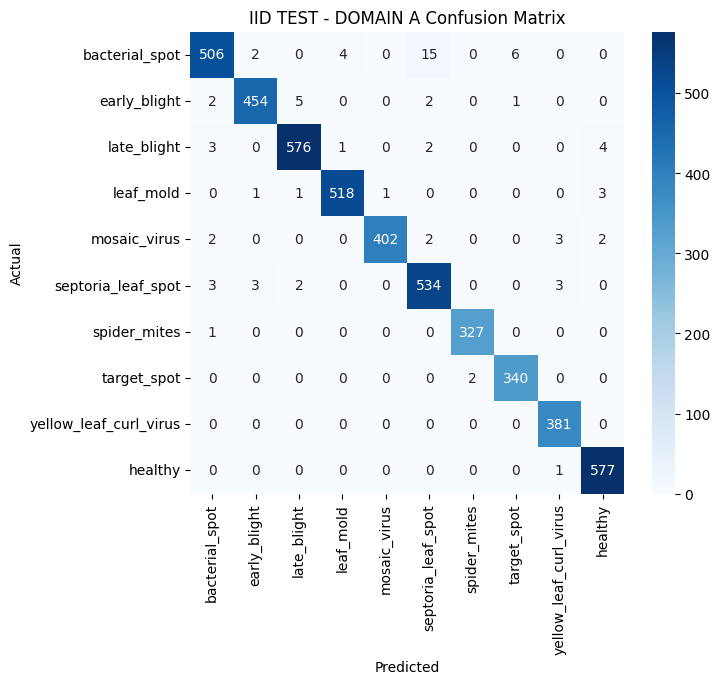


IID TEST - DOMAIN B
                        precision    recall  f1-score   support

        bacterial_spot       1.00      0.98      0.99       165
          early_blight       1.00      0.99      1.00       165
           late_blight       1.00      1.00      1.00       165
             leaf_mold       1.00      1.00      1.00       165
          mosaic_virus       1.00      1.00      1.00       165
    septoria_leaf_spot       1.00      0.99      0.99       165
          spider_mites       0.98      1.00      0.99       166
           target_spot       0.96      0.98      0.97       165
yellow_leaf_curl_virus       1.00      1.00      1.00       165
               healthy       1.00      1.00      1.00       165

              accuracy                           0.99      1651
             macro avg       0.99      0.99      0.99      1651
          weighted avg       0.99      0.99      0.99      1651

Balanced Accuracy: 99.33 %


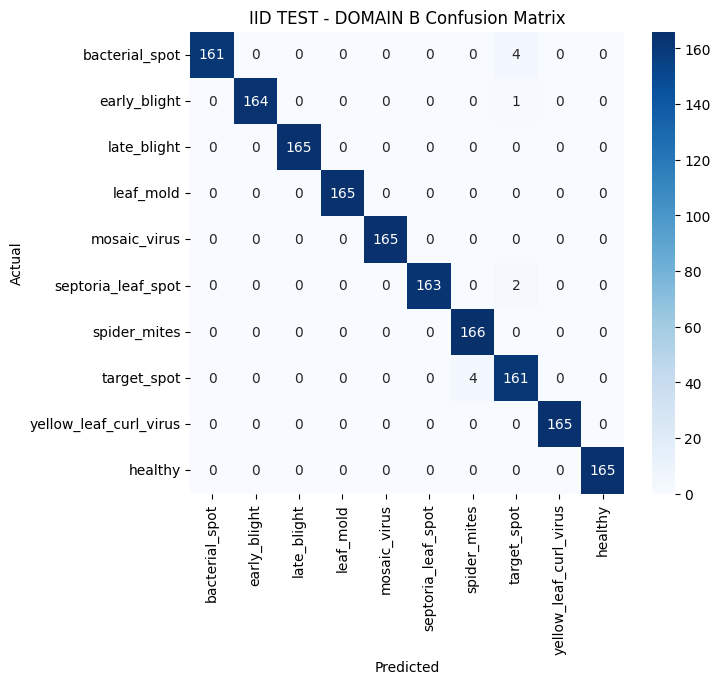


OOD TEST - DOMAIN C
                        precision    recall  f1-score   support

        bacterial_spot       0.90      0.97      0.93      2123
          early_blight       0.99      0.76      0.86      2621
           late_blight       0.88      0.91      0.90      2537
             leaf_mold       0.93      1.00      0.96      1904
          mosaic_virus       1.00      1.00      1.00      1641
    septoria_leaf_spot       0.86      1.00      0.92      1771
          spider_mites       0.93      1.00      0.96      1676
           target_spot       0.93      1.00      0.96      1554
yellow_leaf_curl_virus       1.00      1.00      1.00      4039
               healthy       0.97      0.84      0.90      2327

              accuracy                           0.94     22193
             macro avg       0.94      0.95      0.94     22193
          weighted avg       0.94      0.94      0.94     22193

Balanced Accuracy: 94.75 %


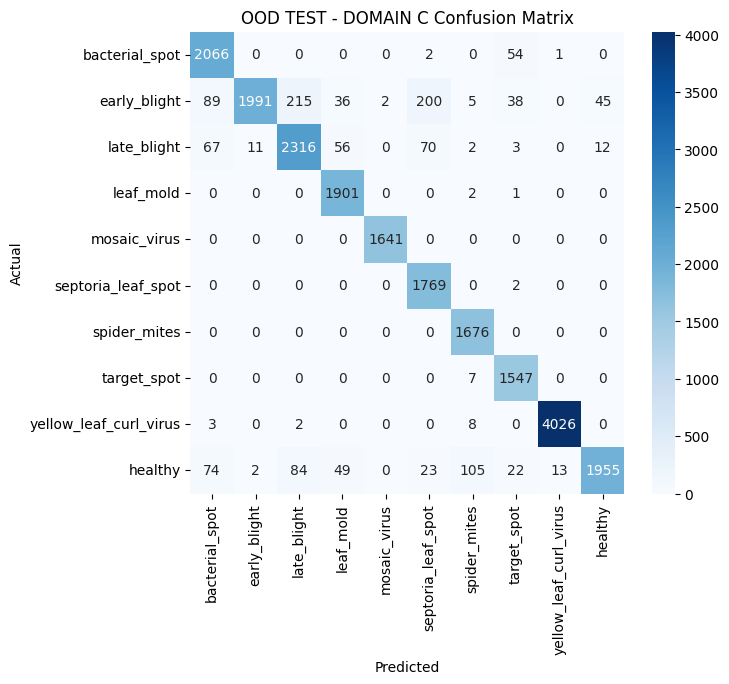

In [ ]:
# ============================================================
# IID + OOD TESTS
# ============================================================

evaluate_domain(test_loader_A,"IID TEST - DOMAIN A")
evaluate_domain(test_loader_B,"IID TEST - DOMAIN B")
evaluate_domain(test_loader_C,"OOD TEST - DOMAIN C")